Cell Initiated
Loaded 20-bin results: 360 rows
Loaded 9-bin results: 360 rows
Cell Completed
Cell Initiated

--- 20-bin: All 9 params free ---


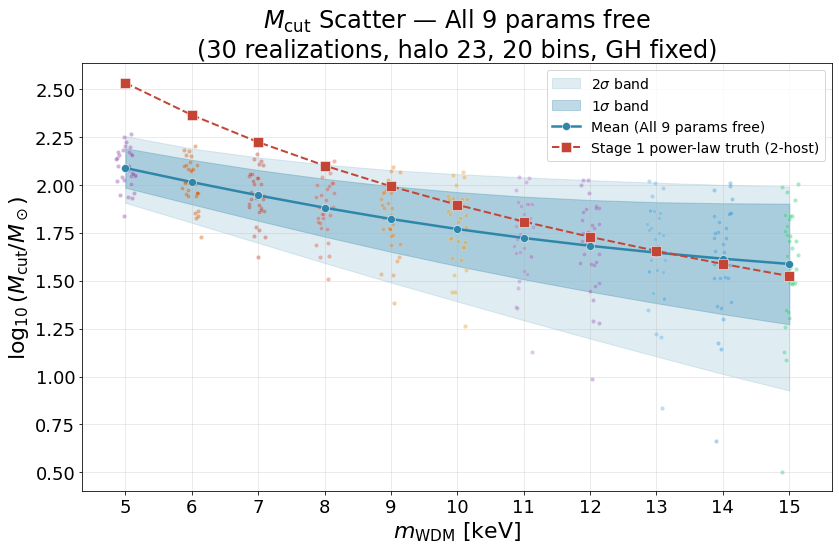


--- 20-bin: M_cut only free ---


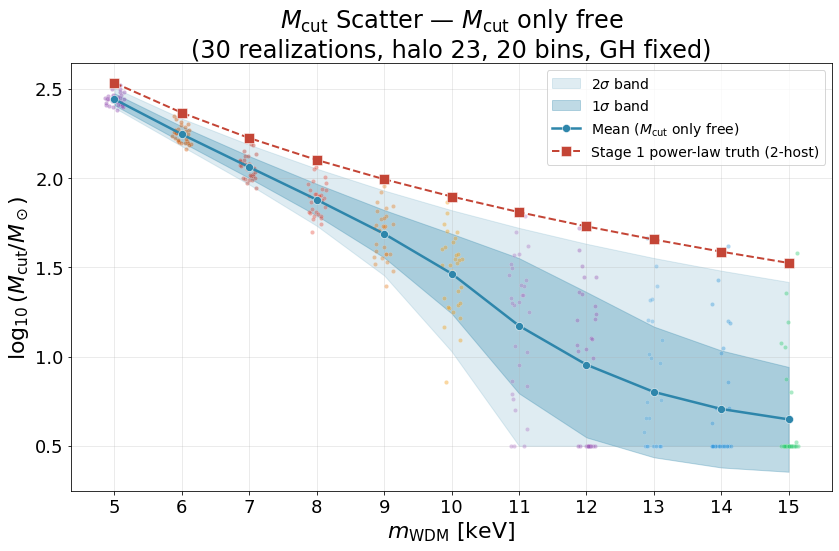


--- 9-bin: All 9 params free ---


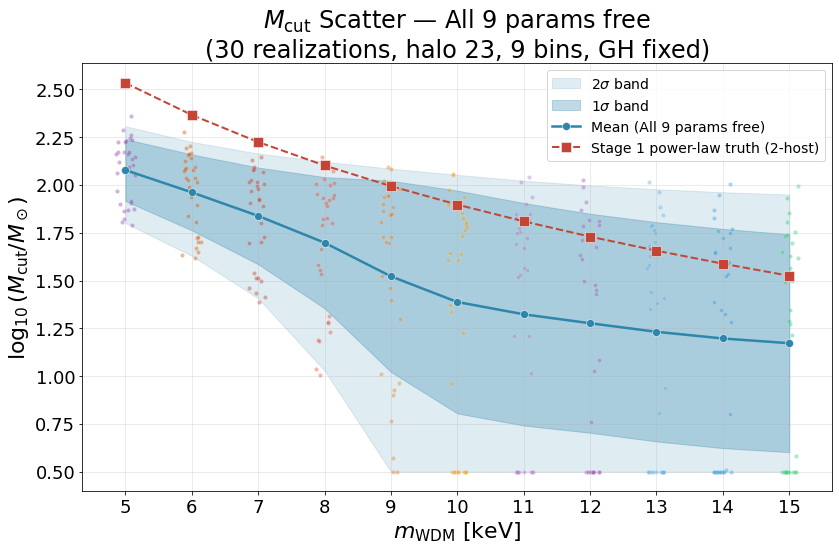


--- 9-bin: M_cut only free ---


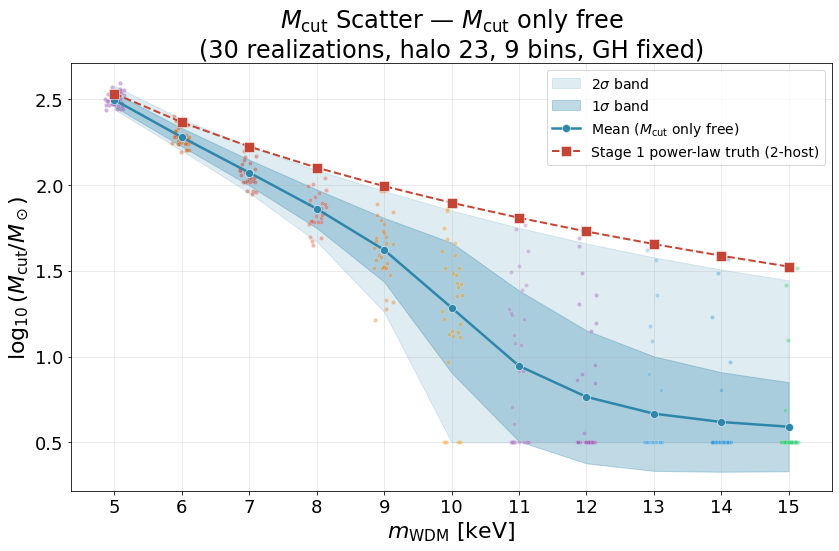

Cell Completed
Cell Initiated

--- 20-bin: Combined ---


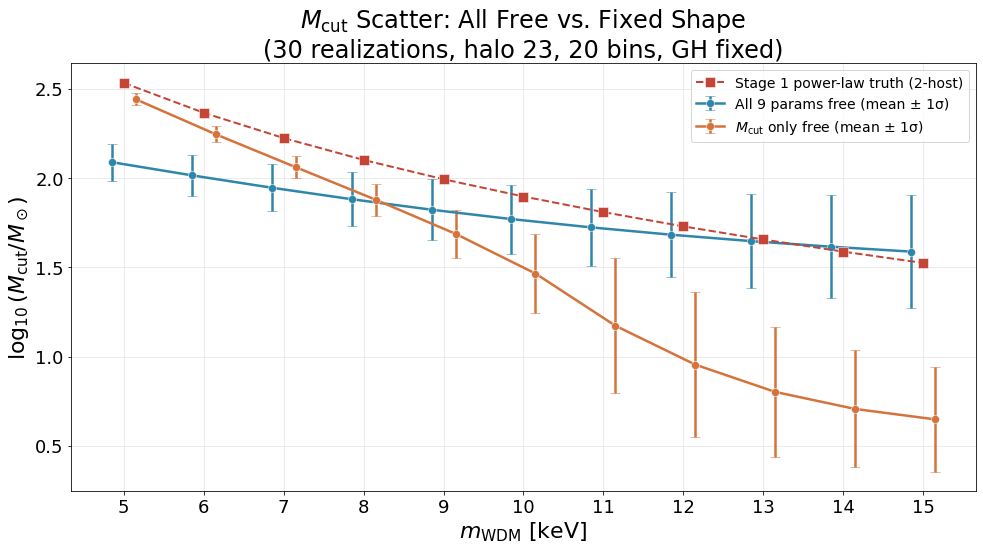


--- 9-bin: Combined ---


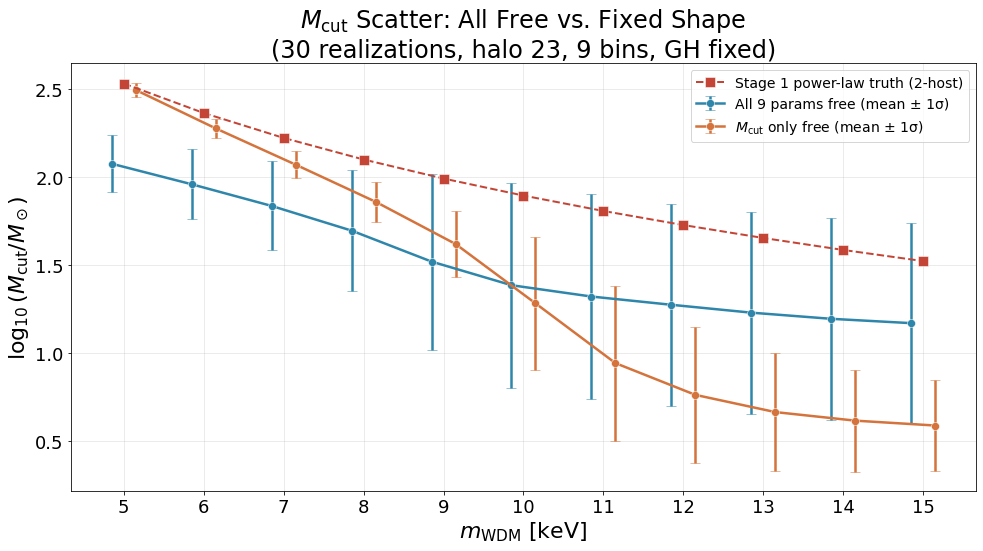

Cell Completed
Cell Initiated

--- 20-bin: A vs M_cut degeneracy ---


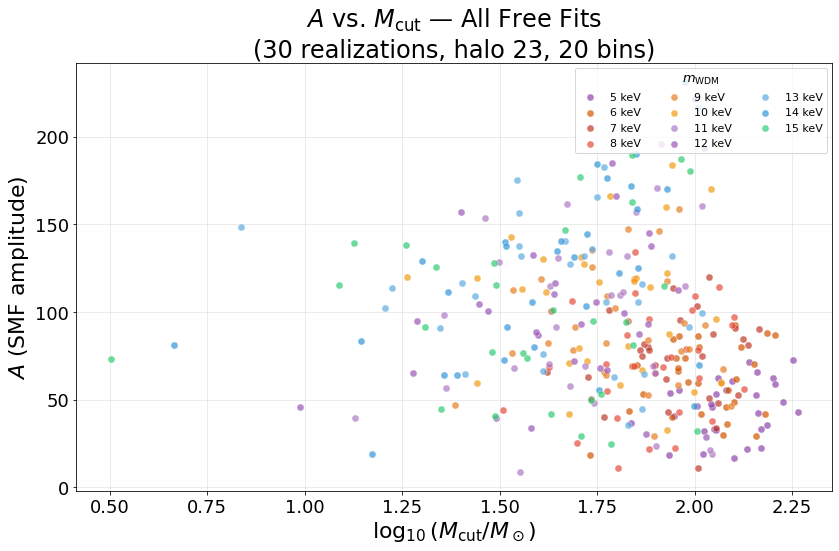


--- 9-bin: A vs M_cut degeneracy ---


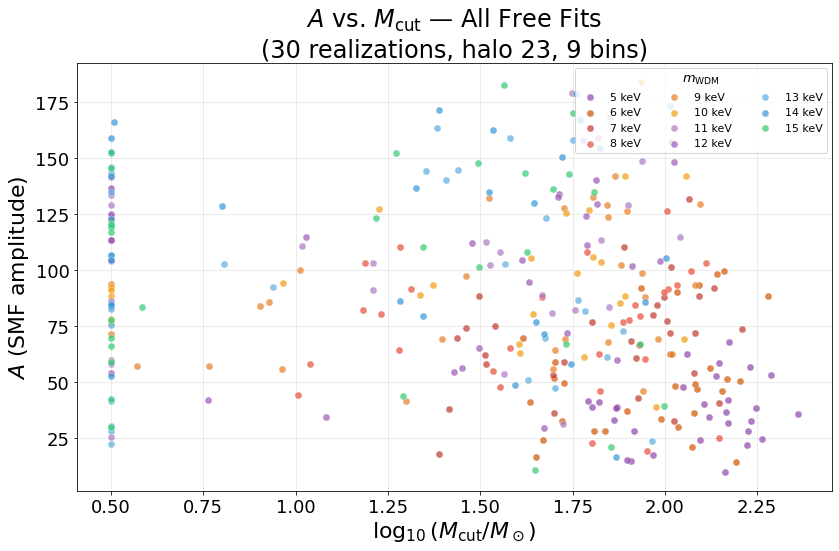

Cell Completed
Cell Initiated

--- 20-bin: All 9 params panel ---


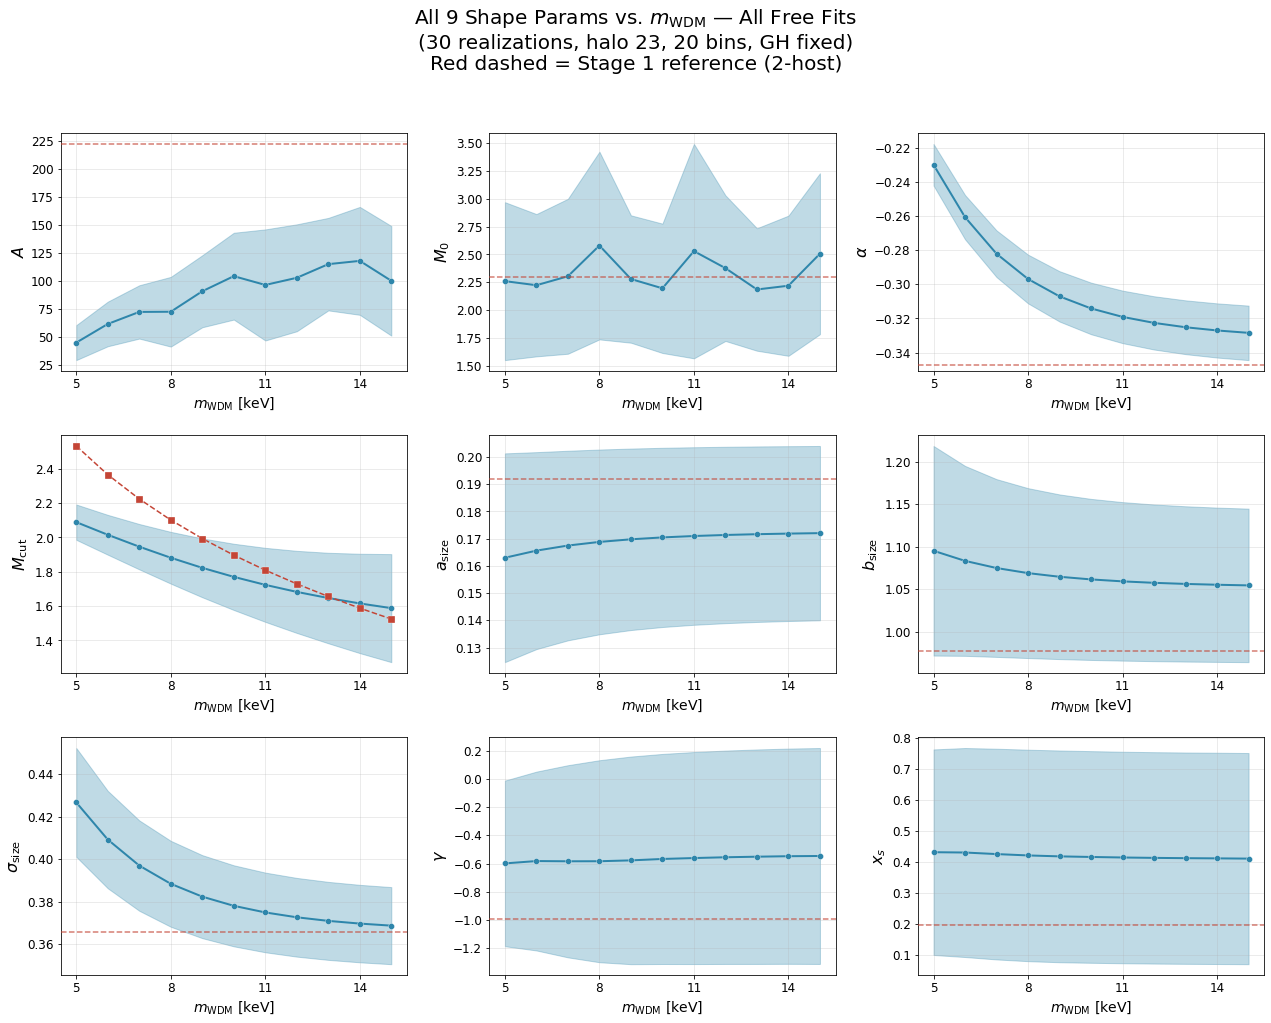


--- 9-bin: All 9 params panel ---


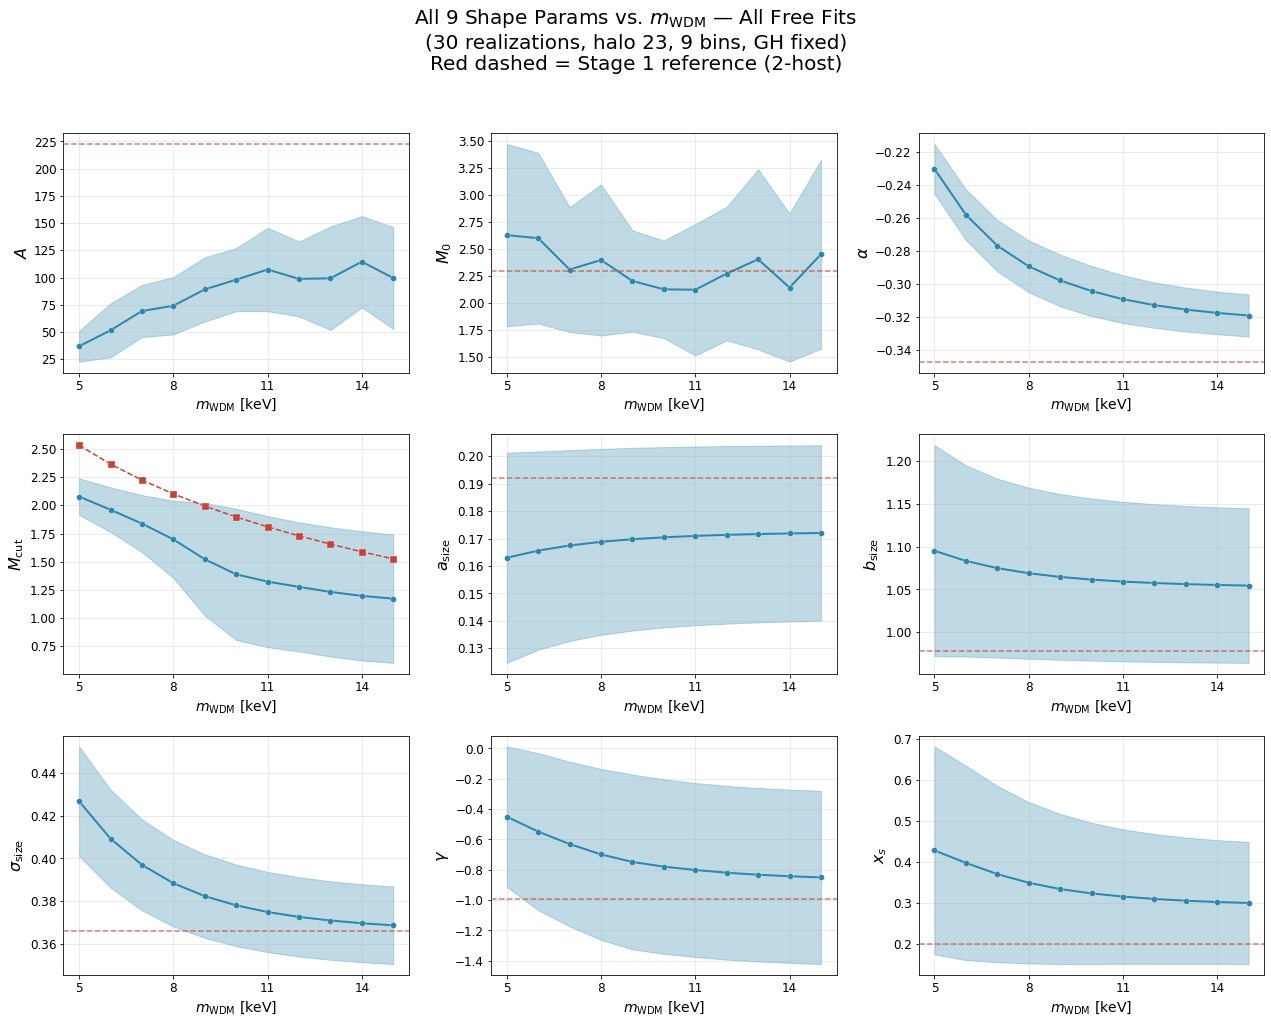

Cell Completed
Cell Initiated

--- 20-bin: CDM M_cut histogram ---


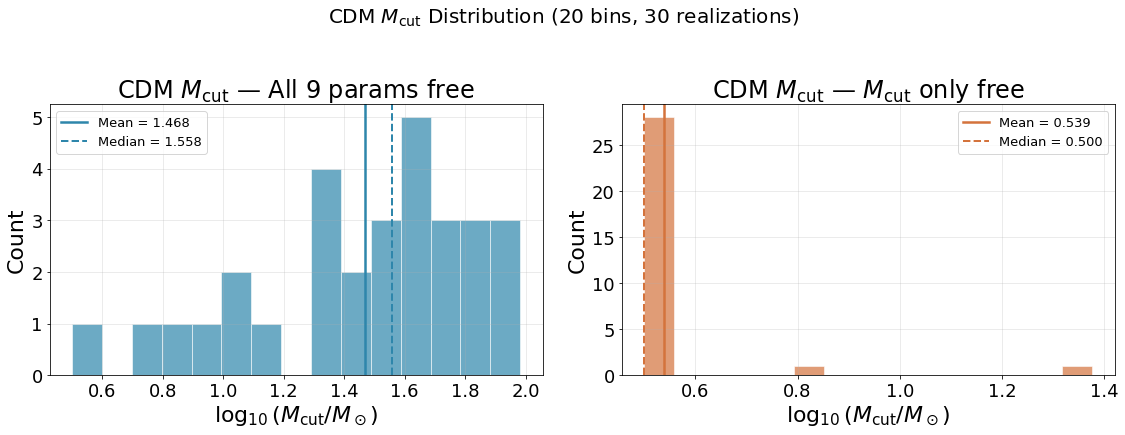


--- 9-bin: CDM M_cut histogram ---


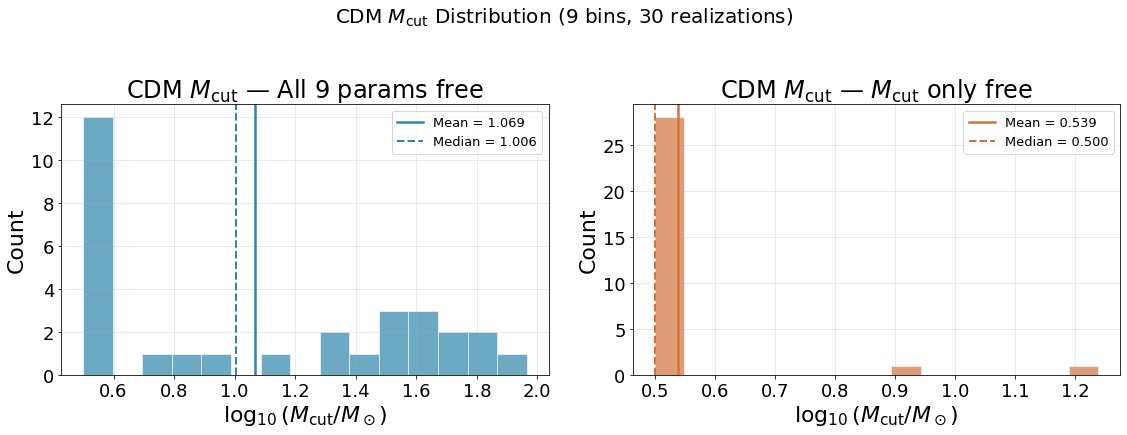

Cell Completed
Cell Initiated

  20-BIN RESULTS SUMMARY

  Pass 2 fixed params (median of Pass 1 all-free fits):
    A            = 82.1942
    M_0          = 2.1929
    alpha        = -0.3102
    a_size       = 0.1672
    b_size       = 1.0597
    sigma_size   = 0.3808
    gamma        = -0.5636
    x_s          = 0.3089

  Cosmology     m_WDM   M_cut(all)   σ(all)   M_cut(fix)   σ(fix)   S1 truth
  ------------------------------------------------------------------------------
  CDM             CDM       1.4682   0.3787       0.5393   0.1676    -0.2170
  WDM_5keV          5       2.0893   0.1047       2.4417   0.0337     2.5334
  WDM_6keV          6       2.0157   0.1181       2.2455   0.0448     2.3660
  WDM_7keV          7       1.9463   0.1345       2.0614   0.0625     2.2245
  WDM_8keV          8       1.8818   0.1535       1.8791   0.0901     2.1019
  WDM_9keV          9       1.8230   0.1744       1.6880   0.1355     1.9937
  WDM_10keV        10       1.7704   0.1964       1.465

In [8]:
print("Cell Initiated")

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import os

# =============================================================================
# GLOBAL PLOT STYLE — matches existing PoC notebooks
# =============================================================================
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'figure.titlesize': 26,
})

# =============================================================================
# COLORS — consistent with Proof_Of_Concept_Pipeline notebooks
# =============================================================================
MAIN_COLOR   = '#2E86AB'   # blue — primary data
TRUTH_COLOR  = '#C44536'   # retro red — S1 truth lines
CORNER_COLOR = '#D4733C'   # burnt orange — second series / corner plots
CDM_COLOR    = '#1ABC9C'   # teal — CDM
NADLER_COLOR = '#F39C12'   # amber — Nadler reference

COLORS = {
    'CDM':       ('#1ABC9C', '#117A65'),
    'WDM_5keV':  ('#8E44AD', '#5B2C6F'),
    'WDM_6keV':  ('#D35400', '#873600'),
    'WDM_7keV':  ('#C0392B', '#7B241C'),
    'WDM_8keV':  ('#E74C3C', '#922B21'),
    'WDM_9keV':  ('#E67E22', '#A04000'),
    'WDM_10keV': ('#F39C12', '#B9770E'),
    'WDM_11keV': ('#AF7AC5', '#7D3C98'),
    'WDM_12keV': ('#9B59B6', '#6C3483'),
    'WDM_13keV': ('#5DADE2', '#2874A6'),
    'WDM_14keV': ('#3498DB', '#21618C'),
    'WDM_15keV': ('#2ECC71', '#1D8348'),
}

# =============================================================================
# CONFIGURATION
# =============================================================================
# Update this path to wherever you SCP'd the pkl files
PKL_DIR = './'  # <-- adjust if needed

COSMO_NAMES = ['CDM'] + [f'WDM_{m}keV' for m in [5,6,7,8,9,10,11,12,13,14,15]]
MWDM_VALUES = [100.0, 5,6,7,8,9,10,11,12,13,14,15]
COSMO_TO_MWDM = dict(zip(COSMO_NAMES, MWDM_VALUES))
WDM_ONLY = [c for c in COSMO_NAMES if c != 'CDM']
WDM_MASSES = [5,6,7,8,9,10,11,12,13,14,15]

M_WDM_PIVOT = 10.0
LOG10_PIVOT = np.log10(M_WDM_PIVOT)

# theta9 ordering: [A, M_0, alpha, M_cut, a_size, b_size, sigma_size, gamma, x_s]
PARAM_NAMES_9 = ['A', r'$M_0$', r'$\alpha$', r'$M_{\mathrm{cut}}$',
                  r'$a_{\mathrm{size}}$', r'$b_{\mathrm{size}}$',
                  r'$\sigma_{\mathrm{size}}$', r'$\gamma$', r'$x_s$']

# =============================================================================
# LOAD DATA
# =============================================================================
data = {}
for nbins in [20, 9]:
    pkl_path = os.path.join(PKL_DIR, f'mcut_scatter_results_{nbins}bins_compat.pkl')
    if os.path.exists(pkl_path):
        with open(pkl_path, 'rb') as f:
            data[nbins] = pickle.load(f)
        # Reconstruct DataFrame from the plain dict
        data[nbins]['results_df'] = pd.DataFrame(data[nbins]['results_df_dict'])
        print(f"Loaded {nbins}-bin results: {len(data[nbins]['results_df'])} rows")
    else:
        print(f"WARNING: {pkl_path} not found — skipping")

assert len(data) > 0, "No pkl files found. Check PKL_DIR path."


def s1_mcut_for_cosmo(m_wdm, s1_ref):
    return s1_ref['M_cut_10'] + s1_ref['b_pow'] * (LOG10_PIVOT - np.log10(m_wdm))


print("Cell Completed")

# %%
print("Cell Initiated")
# =============================================================================
# PLOT 1: M_cut vs m_WDM — individual version (one per pass × binning)
# =============================================================================

def plot_mcut_scatter(results_df, col, version_label, n_bins, s1_ref,
                      output_path=None):
    """M_cut vs m_WDM with 1σ/2σ bands, individual scatter, and S1 truth."""
    fig, ax = plt.subplots(figsize=(12, 8))

    x_plot, y_mean, y_std, y_lo2, y_hi2, y_all = [], [], [], [], [], []

    for cosmo in WDM_ONLY:
        m_wdm = COSMO_TO_MWDM[cosmo]
        vals = results_df[results_df['cosmo'] == cosmo][col].dropna().values
        if len(vals) == 0:
            continue
        x_plot.append(m_wdm)
        y_mean.append(np.mean(vals))
        y_std.append(np.std(vals))
        y_lo2.append(np.percentile(vals, 2.5))
        y_hi2.append(np.percentile(vals, 97.5))
        y_all.append(vals)

    x_plot = np.array(x_plot, dtype=float)
    y_mean = np.array(y_mean)
    y_std = np.array(y_std)
    y_lo2 = np.array(y_lo2)
    y_hi2 = np.array(y_hi2)

    # 2σ band
    ax.fill_between(x_plot, y_lo2, y_hi2, alpha=0.15, color=MAIN_COLOR,
                    label=r'$2\sigma$ band')
    # 1σ band
    ax.fill_between(x_plot, y_mean - y_std, y_mean + y_std,
                    alpha=0.3, color=MAIN_COLOR, label=r'$1\sigma$ band')

    # Individual realizations (jittered, colored by cosmology)
    rng = np.random.default_rng(42)
    for i, m_wdm in enumerate(x_plot):
        cosmo = f'WDM_{int(m_wdm)}keV'
        color = COLORS.get(cosmo, (MAIN_COLOR,))[0]
        jitter = rng.uniform(-0.15, 0.15, len(y_all[i]))
        ax.scatter(np.full_like(y_all[i], m_wdm) + jitter, y_all[i],
                   s=18, alpha=0.4, color=color, edgecolors='white',
                   linewidth=0.3, zorder=2)

    # Mean line
    ax.plot(x_plot, y_mean, 'o-', color=MAIN_COLOR, lw=2.5, ms=8, zorder=5,
            markeredgecolor='white', markeredgewidth=0.5,
            label=f'Mean ({version_label})')

    # S1 truth line
    mcut_truth = np.array([s1_mcut_for_cosmo(m, s1_ref) for m in x_plot])
    ax.plot(x_plot, mcut_truth, 's--', color=TRUTH_COLOR, ms=10, lw=2,
            markeredgecolor='white', markeredgewidth=0.5,
            label='Stage 1 power-law truth (2-host)', zorder=5)

    ax.set_xlabel(r'$m_{\mathrm{WDM}}$ [keV]')
    ax.set_ylabel(r'$\log_{10}(M_{\mathrm{cut}} / M_\odot)$')
    ax.set_title(f'$M_{{\\mathrm{{cut}}}}$ Scatter — {version_label}\n'
                 f'(30 realizations, halo 23, {n_bins} bins, GH fixed)')
    ax.legend(fontsize=14, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(WDM_MASSES)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"  Saved: {output_path}")
    plt.show()
    plt.close()


for nbins, d in data.items():
    df = d['results_df']
    s1 = d['s1_reference']
    print(f"\n--- {nbins}-bin: All 9 params free ---")
    plot_mcut_scatter(df, 'mcut_allfree', 'All 9 params free', nbins, s1)
    print(f"\n--- {nbins}-bin: M_cut only free ---")
    plot_mcut_scatter(df, 'mcut_mcutonly', r'$M_{\mathrm{cut}}$ only free',
                      nbins, s1)

print("Cell Completed")


# %%
print("Cell Initiated")
# =============================================================================
# PLOT 2: Combined overlay — All Free vs M_cut Only
# =============================================================================

def plot_combined(results_df, n_bins, s1_ref, output_path=None):
    fig, ax = plt.subplots(figsize=(14, 8))

    series = {
        'allfree':  {'color': MAIN_COLOR,   'label': 'All 9 params free',
                     'offset': -0.15},
        'mcutonly': {'color': CORNER_COLOR,  'label': r'$M_{\mathrm{cut}}$ only free',
                     'offset': 0.15},
    }

    for version, cfg in series.items():
        col = f'mcut_{version}'
        x_plot, y_mean, y_std = [], [], []

        for cosmo in WDM_ONLY:
            m_wdm = COSMO_TO_MWDM[cosmo]
            vals = results_df[results_df['cosmo'] == cosmo][col].dropna().values
            if len(vals) == 0:
                continue
            x_plot.append(m_wdm)
            y_mean.append(np.mean(vals))
            y_std.append(np.std(vals))

        x_plot = np.array(x_plot, dtype=float)
        y_mean = np.array(y_mean)
        y_std = np.array(y_std)

        ax.errorbar(x_plot + cfg['offset'], y_mean, yerr=y_std,
                    fmt='o-', capsize=5, capthick=2, ms=8,
                    color=cfg['color'], ecolor=cfg['color'], lw=2.5,
                    markeredgecolor='white', markeredgewidth=0.5,
                    label=f'{cfg["label"]} (mean ± 1σ)', zorder=4)

    # S1 truth
    m_wdm_grid = np.array(WDM_MASSES, dtype=float)
    mcut_truth = np.array([s1_mcut_for_cosmo(m, s1_ref) for m in m_wdm_grid])
    ax.plot(m_wdm_grid, mcut_truth, 's--', color=TRUTH_COLOR, ms=10, lw=2,
            markeredgecolor='white', markeredgewidth=0.5,
            label='Stage 1 power-law truth (2-host)', zorder=5)

    ax.set_xlabel(r'$m_{\mathrm{WDM}}$ [keV]')
    ax.set_ylabel(r'$\log_{10}(M_{\mathrm{cut}} / M_\odot)$')
    ax.set_title(f'$M_{{\\mathrm{{cut}}}}$ Scatter: All Free vs. Fixed Shape\n'
                 f'(30 realizations, halo 23, {n_bins} bins, GH fixed)')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(WDM_MASSES)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"  Saved: {output_path}")
    plt.show()
    plt.close()


for nbins, d in data.items():
    print(f"\n--- {nbins}-bin: Combined ---")
    plot_combined(d['results_df'], nbins, d['s1_reference'])

print("Cell Completed")


# %%
print("Cell Initiated")
# =============================================================================
# PLOT 3: A vs M_cut — degeneracy diagnostic
# =============================================================================

def plot_A_vs_Mcut(results_df, n_bins, output_path=None):
    fig, ax = plt.subplots(figsize=(12, 8))

    for cosmo in WDM_ONLY:
        m_wdm = COSMO_TO_MWDM[cosmo]
        sub = results_df[results_df['cosmo'] == cosmo]
        A_vals, Mcut_vals = [], []
        for _, row in sub.iterrows():
            t9 = row['theta9_allfree']
            if hasattr(t9, '__len__') and len(t9) == 9 and np.isfinite(t9[0]):
                A_vals.append(t9[0])
                Mcut_vals.append(t9[3])
        if len(A_vals) == 0:
            continue
        color = COLORS.get(cosmo, (MAIN_COLOR,))[0]
        ax.scatter(Mcut_vals, A_vals, s=50, alpha=0.7, color=color,
                   edgecolors='white', linewidth=0.5, zorder=3,
                   label=f'{int(m_wdm)} keV')

    ax.set_xlabel(r'$\log_{10}(M_{\mathrm{cut}} / M_\odot)$')
    ax.set_ylabel(r'$A$ (SMF amplitude)')
    ax.set_title(f'$A$ vs. $M_{{\\mathrm{{cut}}}}$ — All Free Fits\n'
                 f'(30 realizations, halo 23, {n_bins} bins)')
    ax.legend(fontsize=11, ncol=3, loc='upper right',
              title=r'$m_{\mathrm{WDM}}$', title_fontsize=13)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"  Saved: {output_path}")
    plt.show()
    plt.close()


for nbins, d in data.items():
    print(f"\n--- {nbins}-bin: A vs M_cut degeneracy ---")
    plot_A_vs_Mcut(d['results_df'], nbins)

print("Cell Completed")


# %%
print("Cell Initiated")
# =============================================================================
# PLOT 4: All 9 parameters vs m_WDM — see which params vary with cosmology
# =============================================================================

def plot_all_params_vs_mwdm(results_df, n_bins, s1_ref, output_path=None):
    """3×3 grid: each of the 9 shape params vs m_WDM from the all-free fits."""
    param_indices = list(range(9))
    param_labels = [r'$A$', r'$M_0$', r'$\alpha$', r'$M_{\mathrm{cut}}$',
                    r'$a_{\mathrm{size}}$', r'$b_{\mathrm{size}}$',
                    r'$\sigma_{\mathrm{size}}$', r'$\gamma$', r'$x_s$']

    # S1 reference values (same ordering as theta9)
    s1_vals = [s1_ref['A'], s1_ref['M_0'], s1_ref['alpha'],
               None,  # M_cut varies with cosmology
               s1_ref['a_size'], s1_ref['b_size'],
               s1_ref['sigma_size'], s1_ref['gamma'], s1_ref['x_s']]

    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    axes = axes.ravel()

    for idx, (ax, plabel) in enumerate(zip(axes, param_labels)):
        x_plot, y_mean, y_std, y_all = [], [], [], []

        for cosmo in WDM_ONLY:
            m_wdm = COSMO_TO_MWDM[cosmo]
            sub = results_df[results_df['cosmo'] == cosmo]
            vals = []
            for _, row in sub.iterrows():
                t9 = row['theta9_allfree']
                if hasattr(t9, '__len__') and len(t9) == 9 and np.isfinite(t9[idx]):
                    vals.append(t9[idx])
            if len(vals) == 0:
                continue
            vals = np.array(vals)
            x_plot.append(m_wdm)
            y_mean.append(np.mean(vals))
            y_std.append(np.std(vals))
            y_all.append(vals)

        x_plot = np.array(x_plot, dtype=float)
        y_mean = np.array(y_mean)
        y_std = np.array(y_std)

        # 1σ band
        ax.fill_between(x_plot, y_mean - y_std, y_mean + y_std,
                        alpha=0.3, color=MAIN_COLOR)
        ax.plot(x_plot, y_mean, 'o-', color=MAIN_COLOR, lw=2, ms=6,
                markeredgecolor='white', markeredgewidth=0.3, zorder=4)

        # S1 truth
        if idx == 3:  # M_cut varies with cosmology
            mcut_truth = [s1_mcut_for_cosmo(m, s1_ref) for m in x_plot]
            ax.plot(x_plot, mcut_truth, 's--', color=TRUTH_COLOR, ms=7, lw=1.5,
                    markeredgecolor='white', markeredgewidth=0.3, zorder=5)
        elif s1_vals[idx] is not None:
            ax.axhline(s1_vals[idx], color=TRUTH_COLOR, ls='--', lw=1.5,
                       alpha=0.7, zorder=5)

        ax.set_ylabel(plabel, fontsize=16)
        ax.set_xlabel(r'$m_{\mathrm{WDM}}$ [keV]', fontsize=14)
        ax.set_xticks([5, 8, 11, 14])
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=12)

    fig.suptitle(f'All 9 Shape Params vs. $m_{{\\mathrm{{WDM}}}}$ — All Free Fits\n'
                 f'(30 realizations, halo 23, {n_bins} bins, GH fixed)\n'
                 f'Red dashed = Stage 1 reference (2-host)',
                 fontsize=20, y=1.02)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"  Saved: {output_path}")
    plt.show()
    plt.close()


for nbins, d in data.items():
    print(f"\n--- {nbins}-bin: All 9 params panel ---")
    plot_all_params_vs_mwdm(d['results_df'], nbins, d['s1_reference'])

print("Cell Completed")


# %%
print("Cell Initiated")
# =============================================================================
# PLOT 5: CDM M_cut distribution — histogram
# =============================================================================

def plot_cdm_mcut_hist(results_df, n_bins, output_path=None):
    """Histogram of M_cut values for CDM across realizations."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, (col, label, color) in zip(axes, [
        ('mcut_allfree', 'All 9 params free', MAIN_COLOR),
        ('mcut_mcutonly', r'$M_{\mathrm{cut}}$ only free', CORNER_COLOR),
    ]):
        cdm_vals = results_df[results_df['cosmo'] == 'CDM'][col].dropna().values
        ax.hist(cdm_vals, bins=15, color=color, alpha=0.7,
                edgecolor='white', linewidth=0.8)
        ax.axvline(np.mean(cdm_vals), color=color, ls='-', lw=2.5,
                   label=f'Mean = {np.mean(cdm_vals):.3f}')
        ax.axvline(np.median(cdm_vals), color=color, ls='--', lw=2,
                   label=f'Median = {np.median(cdm_vals):.3f}')
        ax.set_xlabel(r'$\log_{10}(M_{\mathrm{cut}} / M_\odot)$')
        ax.set_ylabel('Count')
        ax.set_title(f'CDM $M_{{\\mathrm{{cut}}}}$ — {label}')
        ax.legend(fontsize=13)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'CDM $M_{{\\mathrm{{cut}}}}$ Distribution ({n_bins} bins, 30 realizations)',
                 fontsize=20, y=1.02)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"  Saved: {output_path}")
    plt.show()
    plt.close()


for nbins, d in data.items():
    print(f"\n--- {nbins}-bin: CDM M_cut histogram ---")
    plot_cdm_mcut_hist(d['results_df'], nbins)

print("Cell Completed")


# %%
print("Cell Initiated")
# =============================================================================
# SUMMARY TABLE — print to console
# =============================================================================

for nbins, d in data.items():
    df = d['results_df']
    s1 = d['s1_reference']
    fp = d['fixed_params_from_p1']

    print(f"\n{'='*80}")
    print(f"  {nbins}-BIN RESULTS SUMMARY")
    print(f"{'='*80}")

    print(f"\n  Pass 2 fixed params (median of Pass 1 all-free fits):")
    for k, v in fp.items():
        print(f"    {k:<12} = {v:.4f}")

    print(f"\n  {'Cosmology':<12} {'m_WDM':>6} "
          f"{'M_cut(all)':>12} {'σ(all)':>8} "
          f"{'M_cut(fix)':>12} {'σ(fix)':>8} "
          f"{'S1 truth':>10}")
    print(f"  {'-'*78}")

    for cosmo in COSMO_NAMES:
        m_wdm = COSMO_TO_MWDM[cosmo]
        sub = df[df['cosmo'] == cosmo]
        mcut_all = sub['mcut_allfree'].dropna()
        mcut_fix = sub['mcut_mcutonly'].dropna()
        mcut_s1 = s1_mcut_for_cosmo(m_wdm, s1)
        m_label = 'CDM' if m_wdm > 50 else f'{m_wdm:.0f}'

        print(f"  {cosmo:<12} {m_label:>6} "
              f"{mcut_all.mean():>12.4f} {mcut_all.std():>8.4f} "
              f"{mcut_fix.mean():>12.4f} {mcut_fix.std():>8.4f} "
              f"{mcut_s1:>10.4f}")

print("Cell Completed")
